In [1]:
#importing necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

In [2]:
#loading dataset
feature_names = []

with open("spambase.names") as f:
    for line in f:
        line = line.strip()
        #keep lines that define features
        if ":" in line and not line.startswith("|"):
            name = line.split(":")[0]
            feature_names.append(name)

feature_names.append("class")

df = pd.read_csv("spambase.data", header=None, names=feature_names)

#last column is spam label
X = df.drop("class", axis=1)
y = df["class"]

#75% train + 25% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.25, random_state = 1, stratify = y
)

In [3]:
#problem 1
#scale data for logistic regression
scaler1 = StandardScaler()
X_train_scaled = scaler1.fit_transform(X_train)
X_test_scaled = scaler1.transform(X_test)

#train model
log_model = LogisticRegression(max_iter = 2000)
log_model.fit(X_train_scaled, y_train)

#predictions using default threshold of 0.5
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

#confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix")
print(cm)

#metrics
acc = accuracy_score(y_test, y_pred)
err = 1 - acc
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", acc)
print("Error:", err)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

Confusion Matrix
[[665  32]
 [ 44 410]]
Accuracy: 0.9339704604691572
Error: 0.06602953953084278
Precision: 0.9276018099547512
Recall: 0.9030837004405287
F1 Score: 0.9151785714285716


In [4]:
#coefficients for each feature
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

print("Top positive coefficients:")
display(coef_df.sort_values("Coefficient", ascending=False).head(10))

print("Top negative coefficients:")
display(coef_df.sort_values("Coefficient").head(10))

Top positive coefficients:


,Feature,Coefficient
55,capital_run_length_longest,1.519447
52,char_freq_$,1.166311
6,word_freq_remove,1.004574
22,word_freq_000,0.918788
3,word_freq_3d,0.901265
15,word_freq_free,0.861931
53,char_freq_#,0.509367
56,capital_run_length_total,0.453973
21,word_freq_font,0.422643
19,word_freq_credit,0.421731


Top negative coefficients:


,Feature,Coefficient
26,word_freq_george,-4.133725
24,word_freq_hp,-2.177478
45,word_freq_edu,-1.878932
40,word_freq_cs,-1.503235
30,word_freq_telnet,-1.430421
41,word_freq_meeting,-1.399400
34,word_freq_85,-1.323142
28,word_freq_lab,-1.289567
43,word_freq_project,-1.049424
25,word_freq_hpl,-0.953947


In [5]:
#test different thresholds
thresholds = [0.25, 0.5, 0.75, 0.9]
results = []

for t in thresholds:
    pred_t = (y_prob >= t).astype(int)
    results.append([
        t,
        accuracy_score(y_test, pred_t),
        precision_score(y_test, pred_t, zero_division = 0),
        recall_score(y_test, pred_t, zero_division = 0),
        f1_score(y_test, pred_t, zero_division = 0)
    ])

threshold_df = pd.DataFrame(results, columns = ["Threshold", "Accuracy", "Precision", "Recall", "F1"])
display(threshold_df)

,Threshold,Accuracy,Precision,Recall,F1
0,0.25,0.899218,0.820076,0.953744,0.881874
1,0.50,0.933970,0.927602,0.903084,0.915179
2,0.75,0.898349,0.964187,0.770925,0.856793
3,0.90,0.852302,0.970199,0.645374,0.775132


In [6]:
#problem 2
#scale data
scaler2 = StandardScaler()
X_train_gd = scaler2.fit_transform(X_train)
X_test_gd = scaler2.transform(X_test)

#add intercept column
X_train_gd = np.c_[np.ones(X_train_gd.shape[0]), X_train_gd]
X_test_gd = np.c_[np.ones(X_test_gd.shape[0]), X_test_gd]

y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

In [7]:
#sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#cross-entropy loss
def cross_entropy(y, p):
    eps = 1e-10
    return -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

#gradient descent for logistic regression
def gd_logistic(X, y, alpha, iters):
    n, d = X.shape
    theta = np.zeros(d)
    losses = []
    
    for i in range(iters):
        preds = sigmoid(X @ theta)
        grad = (1/n) * (X.T @ (preds - y))
        theta = theta - alpha * grad
        losses.append(cross_entropy(y, preds))
        
    return theta, losses

#evaluate theta
def eval_theta_logistic(Xtr, Xte, ytr, yte, theta):
    pred_tr_prob = sigmoid(Xtr @ theta)
    pred_te_prob = sigmoid(Xte @ theta)
    
    pred_tr = (pred_tr_prob >= 0.5).astype(int)
    pred_te = (pred_te_prob >= 0.5).astype(int)
    
    return {
        "train_accuracy": accuracy_score(ytr, pred_tr),
        "train_precision": precision_score(ytr, pred_tr, zero_division=0),
        "train_recall": recall_score(ytr, pred_tr, zero_division=0),
        "train_f1": f1_score(ytr, pred_tr, zero_division=0),
        "test_accuracy": accuracy_score(yte, pred_te),
        "test_precision": precision_score(yte, pred_te, zero_division=0),
        "test_recall": recall_score(yte, pred_te, zero_division=0),
        "test_f1": f1_score(yte, pred_te, zero_division=0)
    }

In [8]:
alphas = [0.001, 0.01, 0.1]
rows_loss = []
rows_metrics = []

for a in alphas:
    theta_gd, losses = gd_logistic(X_train_gd, y_train_np, a, 100)
    
    rows_loss.append({
        "alpha": a,
        "loss_10": losses[9],
        "loss_50": losses[49],
        "loss_100": losses[99]
    })
    
    metrics = eval_theta_logistic(X_train_gd, X_test_gd, y_train_np, y_test_np, theta_gd)
    rows_metrics.append({
        "alpha": a,
        **metrics
    })

loss_df = pd.DataFrame(rows_loss)
metric_df = pd.DataFrame(rows_metrics)

display(loss_df)
display(metric_df)

#package model metrics
train_pred_pkg = log_model.predict(X_train_scaled)
test_pred_pkg = log_model.predict(X_test_scaled)

package_df = pd.DataFrame([{
    "train_accuracy": accuracy_score(y_train, train_pred_pkg),
    "train_precision": precision_score(y_train, train_pred_pkg),
    "train_recall": recall_score(y_train, train_pred_pkg),
    "train_f1": f1_score(y_train, train_pred_pkg),
    "test_accuracy": accuracy_score(y_test, test_pred_pkg),
    "test_precision": precision_score(y_test, test_pred_pkg),
    "test_recall": recall_score(y_test, test_pred_pkg),
    "test_f1": f1_score(y_test, test_pred_pkg)
}])

display(package_df)

,alpha,loss_10,loss_50,loss_100
0,0.001,0.689061,0.671783,0.652040
1,0.010,0.655298,0.545065,0.471804
2,0.100,0.478609,0.326571,0.289561


,alpha,train_accuracy,train_precision,train_recall,train_f1,test_accuracy,test_precision,test_recall,test_f1
0,0.001,0.890725,0.852224,0.874172,0.863058,0.902693,0.873362,0.881057,0.877193
1,0.010,0.895652,0.873598,0.859455,0.866469,0.909644,0.894144,0.874449,0.884187
2,0.100,0.907826,0.914081,0.845475,0.878440,0.914857,0.921801,0.856828,0.888128


,train_accuracy,train_precision,train_recall,train_f1,test_accuracy,test_precision,test_recall,test_f1
0,0.927826,0.926923,0.886681,0.906356,0.93397,0.927602,0.903084,0.915179


In [9]:
#problem 3
#use cross validation to choose best k for knn
k_list = range(1, 21)
cv_rows = []

for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k)

    acc_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring="accuracy")
    prec_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring="precision")
    rec_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring="recall")

    avg_acc = acc_scores.mean()
    avg_error = 1 - avg_acc
    avg_prec = prec_scores.mean()
    avg_rec = rec_scores.mean()

    cv_rows.append([k, avg_acc, avg_error, avg_prec, avg_rec])

cv_knn_df = pd.DataFrame(
    cv_rows,
    columns=["k", "Accuracy", "Error", "Precision", "Recall"]
)

display(cv_knn_df)

best_k = cv_knn_df.loc[cv_knn_df["Error"].idxmin(), "k"]
print("Best k:", best_k)

,k,Accuracy,Error,Precision,Recall
0,1,0.898261,0.101739,0.873225,0.868287
1,2,0.889275,0.110725,0.928045,0.779249
2,3,0.905507,0.094493,0.888698,0.869023
3,4,0.892464,0.107536,0.912984,0.803527
4,5,0.897971,0.102029,0.885830,0.850632
5,6,0.891884,0.108116,0.910948,0.804244
6,7,0.896232,0.103768,0.889608,0.841038
7,8,0.891884,0.108116,0.906376,0.809388
8,9,0.894493,0.105507,0.886688,0.840295
9,10,0.887536,0.112464,0.900005,0.804241


Best k: 3


In [10]:
#train 3 classifiers
lda_model = LinearDiscriminantAnalysis()
knn_model = KNeighborsClassifier(n_neighbors=best_k)

lda_model.fit(X_train, y_train)
knn_model.fit(X_train_scaled, y_train)

#compare all 3 models on train and test data
models = {
    "Logistic Regression": (log_model, X_train_scaled, X_test_scaled),
    "LDA": (lda_model, X_train, X_test),
    "KNN": (knn_model, X_train_scaled, X_test_scaled)
}

rows = []

for name, info in models.items():
    model, train_data, test_data = info

    train_pred = model.predict(train_data)
    test_pred = model.predict(test_data)

    rows.append([name, "Train",
                 accuracy_score(y_train, train_pred),
                 1 - accuracy_score(y_train, train_pred),
                 precision_score(y_train, train_pred, zero_division = 0),
                 recall_score(y_train, train_pred, zero_division = 0)])

    rows.append([name, "Test",
             accuracy_score(y_test, test_pred),
             1 - accuracy_score(y_test, test_pred),
             precision_score(y_test, test_pred, zero_division = 0),
             recall_score(y_test, test_pred, zero_division = 0)])

compare_df = pd.DataFrame(
    rows,
    columns=["Model", "Data", "Accuracy", "Error", "Precision", "Recall"]
)

display(compare_df)

,Model,Data,Accuracy,Error,Precision,Recall
0,Logistic Regression,Train,0.927826,0.072174,0.926923,0.886681
1,Logistic Regression,Test,0.933970,0.066030,0.927602,0.903084
2,LDA,Train,0.884348,0.115652,0.915225,0.778514
3,LDA,Test,0.891399,0.108601,0.916456,0.797357
4,KNN,Train,0.950145,0.049855,0.945236,0.927152
5,KNN,Test,0.913988,0.086012,0.897092,0.883260


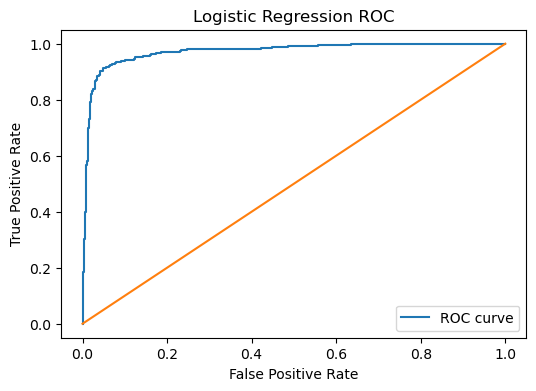

AUC: 0.9719313103988775


In [11]:
#roc curve and auc for logistic regression
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (6,4))
plt.plot(fpr, tpr, label = "ROC curve")
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC")
plt.legend()
plt.show()

print("AUC:", roc_auc)

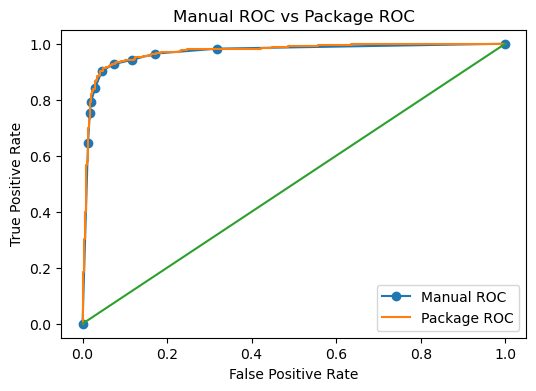

,Threshold,FPR,TPR
0,0.0,1.000000,1.000000
1,0.1,0.318508,0.982379
2,0.2,0.172166,0.964758
3,0.3,0.117647,0.942731
4,0.4,0.074605,0.927313
5,0.5,0.045911,0.903084
6,0.6,0.030129,0.843612
7,0.7,0.020086,0.792952
8,0.8,0.017217,0.753304
9,0.9,0.012912,0.645374


In [12]:
#manual roc points
manual_thresholds = np.arange(0, 1.1, 0.1)
manual_rows = []

for t in manual_thresholds:
    pred_t = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_t).ravel()

    fpr_t = fp / (fp + tn)
    tpr_t = tp / (tp + fn)

    manual_rows.append([t, fpr_t, tpr_t])

manual_df = pd.DataFrame(manual_rows, columns=["Threshold", "FPR", "TPR"])

plt.figure(figsize=(6,4))
plt.plot(manual_df["FPR"], manual_df["TPR"], marker="o", label="Manual ROC")
plt.plot(fpr, tpr, label="Package ROC")

plt.plot([0,1],[0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Manual ROC vs Package ROC")

plt.legend()
plt.show()

display(manual_df)

In [13]:
#problem 4
#scale the data once before cross validation
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


#logistic regression CV
def manual_cv_logistic(X, y, k):

    kf = KFold(n_splits=k, shuffle=True, random_state=1)
    errors = []

    for train_index, test_index in kf.split(X):

        X_train = X.iloc[train_index]
        X_test = X.iloc[test_index]
        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        model = LogisticRegression(max_iter=2000)
        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        error = 1 - accuracy_score(y_test, preds)
        errors.append(error)

    return np.mean(errors)


#LDA CV
def manual_cv_lda(X, y, k):

    kf = KFold(n_splits=k, shuffle=True, random_state=1)
    errors = []

    for train_index, test_index in kf.split(X):

        X_train = X.iloc[train_index]
        X_test = X.iloc[test_index]
        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        model = LinearDiscriminantAnalysis()
        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        error = 1 - accuracy_score(y_test, preds)
        errors.append(error)

    return np.mean(errors)

In [14]:
#run CV for k = 5 and 10
cv_results = []

for k in [5, 10]:

    log_error = manual_cv_logistic(X_scaled, y, k)
    lda_error = manual_cv_lda(X_scaled, y, k)

    cv_results.append([k, "Logistic Regression", log_error])
    cv_results.append([k, "LDA", lda_error])


cv_df = pd.DataFrame(cv_results, columns=["k", "Model", "Average Validation Error"])
display(cv_df)

,k,Model,Average Validation Error
0,5,Logistic Regression,0.074332
1,5,LDA,0.112804
2,10,Logistic Regression,0.074113
3,10,LDA,0.112585
